In [16]:
import sys
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import importlib as imp
import warnings
import yaml

from sklearn import metrics

from utils import utils
import utils.load_utils as load_utils
import visuals.plotting as plotting
import data_loader.data_loaders as data_loader
import cmcrameri.cm as cmr

from utils.DIRECTORIES import SHAPE_DIRECTORY

warnings.filterwarnings("ignore")
torch.set_warn_always(False)

print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"xarray version = {xr.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:35) [Clang 14.0.6 ]
numpy version = 2.2.4
xarray version = 2024.11.0
pytorch version = 2.7.0


## Get predictions

In [17]:
OVERWRITE = False
SAVE_FILES = False
imp.reload(utils)
imp.reload(load_utils)
imp.reload(data_loader)

NETW_NAME = "tas2Rg_all_trend_hptesting"
exp_name_pretrain = None
NETW_NAME = "tas2Rg_amip_trend_random"
exp_name_pretrain = "tas2Rg_all_trend"

seed_lst = range(5)
n_seeds = len(seed_lst)

if NETW_NAME[-10:] == '_hptesting':

    # Load hyperparameter testing configuration
    exp_name = NETW_NAME[:-10]
    with open("config/config_" + exp_name + "_hptesting.yaml") as f:
        config = yaml.safe_load(f)

    if exp_name_pretrain is not None:
        with open("config/hpts_" + exp_name_pretrain + ".yaml") as f:
            hpts = yaml.safe_load(f)
    else:
        with open("config/hpts_" + exp_name + ".yaml") as f:
            hpts = yaml.safe_load(f)

    n_hpts = len(hpts)

    hpt_lst = []
    for jj, hpt in enumerate(hpts):
        config['arch'] = hpts[hpt]['arch']
        config['optimizer'] = hpts[hpt]['optimizer']
        config['expname'] = exp_name + "_" + hpt

        if exp_name_pretrain is not None:
            config['datamaker']['load_pretrained'] = exp_name_pretrain + "_" + hpt
            config['datamaker']['pretrained_seed'] = hpts[hpt]['best_seed'] 

        with open("config/config_" + config['expname'] + ".yaml", 'w') as f:
            yaml.safe_dump(config, f)

        hpt_lst.append(config['expname'])

else:
    n_hpts = 1
    hpt_lst = [NETW_NAME]


true = {}
pred = {}
true['val'] = np.empty((n_seeds, n_hpts), dtype='object')
pred['val'] = np.empty((n_seeds, n_hpts), dtype='object')
true['test'] = np.empty((n_seeds, n_hpts), dtype='object')
pred['test'] = np.empty((n_seeds, n_hpts), dtype='object')
for jj, hpt in enumerate(hpt_lst):
    for ii, seed in enumerate(seed_lst):
        # Load model and data
        (
            config,
            model,
            data,
            _,
            valset,
            testset,
        ) = load_utils.load_model_and_data(hpt, seed, verbose=False)

        # Model evalutation Validation
        true['val'][ii,jj] = data.d_val['y'].flatten()
        pred['val'][ii,jj] = load_utils.make_predictions(model, dataset=valset, device='mps').flatten()

        # Model evalutation Test
        true['test'][ii,jj] = data.d_test['y'].flatten()
        pred['test'][ii,jj] = load_utils.make_predictions(model, dataset=testset, device='mps').flatten()


## Calculate metrics

In [18]:
def get_percentiles(label,preds,th=5):
    p5, p95 = np.percentile(label,(th,100-th))
    
    idx5  = (label<=p5 )
    idx95 = (label>=p95)

    return label[idx5], preds[idx5], label[idx95], preds[idx95]

def mean_error(labels,preds):
    return np.mean(labels-preds)

In [30]:
test_set = 'val'
percentile_th = 5

mse_val = np.empty((n_seeds,n_hpts))
r2_val = np.empty((n_seeds,n_hpts))
mse_test = np.empty((n_seeds,n_hpts))
r2_test = np.empty((n_seeds,n_hpts))

MSE = np.empty((n_seeds,n_hpts))
MAE = np.empty((n_seeds,n_hpts))
MXE  = np.empty((n_seeds,n_hpts))
ME  = np.empty((n_seeds,n_hpts))
R2  = np.empty((n_seeds,n_hpts))

MSE_5 = np.empty((n_seeds,n_hpts))
MAE_5 = np.empty((n_seeds,n_hpts))
MXE_5  = np.empty((n_seeds,n_hpts))
ME_5  = np.empty((n_seeds,n_hpts))
R2_5  = np.empty((n_seeds,n_hpts))

MSE_95 = np.empty((n_seeds,n_hpts))
MAE_95 = np.empty((n_seeds,n_hpts))
MXE_95  = np.empty((n_seeds,n_hpts))
ME_95  = np.empty((n_seeds,n_hpts))
R2_95  = np.empty((n_seeds,n_hpts))


for jj, hpt in enumerate(hpt_lst):
    print("*********  "+hpt+": "+test_set+"  *********")
    for ii, seed in enumerate(seed_lst):

        true5, pred5, true95, pred95 = get_percentiles(true[test_set][ii,jj], pred[test_set][ii,jj], th=percentile_th)

        # Metrics (Validation, testing, OOS)
        MSE[ii,jj] = metrics.mean_squared_error(
                true[test_set][ii,jj], pred[test_set][ii,jj]
            )
        MAE[ii,jj] = metrics.mean_absolute_error(
                true[test_set][ii,jj], pred[test_set][ii,jj]
            )
        MXE[ii,jj] = metrics.max_error(
                true[test_set][ii,jj], pred[test_set][ii,jj]
            )
        ME[ii,jj] = mean_error(
                true[test_set][ii,jj], pred[test_set][ii,jj]
            )
        R2[ii,jj] = metrics.r2_score(
                true[test_set][ii,jj], pred[test_set][ii,jj]
            )
        
        MSE_5[ii,jj] = metrics.mean_squared_error(
                true5, pred5
            )
        MAE_5[ii,jj] = metrics.mean_absolute_error(
                true5, pred5
            )
        MXE_5[ii,jj] = metrics.max_error(
                true5, pred5
            )
        ME_5[ii,jj] = mean_error(
                true5, pred5
            )
        R2_5[ii,jj] = metrics.r2_score(
                true5, pred5
            )
        
        MSE_95[ii,jj] = metrics.mean_squared_error(
                true95, pred95
            )
        MAE_95[ii,jj] = metrics.mean_absolute_error(
                true95, pred95
            )
        MXE_95[ii,jj] = metrics.max_error(
                true95, pred95
            )
        ME_95[ii,jj] = mean_error(
                true95, pred95
            )
        R2_95[ii,jj] = metrics.r2_score(
                true95, pred95
            )
        print("Seed "+str(seed).ljust(5)+":  "\
            +"mse = "+plotting.num_lab(MSE[ii,jj],3).ljust(6,'0')\
            +", mae = "+plotting.num_lab(MAE[ii,jj],3).ljust(5,'0')\
            +", mxe = "+plotting.num_lab(MXE[ii,jj],3).ljust(5,'0')\
            +", r2 = "+plotting.num_lab(R2[ii,jj],3).ljust(5,'0')\
            +", me = "+plotting.num_lab(ME[ii,jj],3).ljust(5,'0')\
        )
    # PREDICTIONS_DIRECTORY = '/rugenstein-analysis/senne/BACKUP/toa_sst_models_MacBook/saved_predictions/'
    print("BEST SEED = ", np.argmin(MSE[:,jj]))
print("")
print("***************")
print("")
print(" MSE    R2     MAE    MXE    ME")
best_mem_MSE = np.unravel_index(np.argmin(MSE, axis=None), MSE.shape)
best_mem_R2  = np.unravel_index(np.argmax(R2,  axis=None),  R2.shape)
best_mem_MAE = np.unravel_index(np.argmin(MAE, axis=None), MAE.shape)
best_mem_MXE = np.unravel_index(np.argmin(MXE, axis=None), MXE.shape)
best_mem_ME  = np.unravel_index(np.argmin(np.abs(ME), axis=None), ME.shape)
print(best_mem_MSE,best_mem_R2,best_mem_MAE,best_mem_MXE,best_mem_ME)

best_mem_MSE_5 = np.unravel_index(np.argmin(MSE_5, axis=None), MSE.shape)
best_mem_R2_5  = np.unravel_index(np.argmax(R2_5,  axis=None),  R2.shape)
best_mem_MAE_5 = np.unravel_index(np.argmin(MAE_5, axis=None), MAE.shape)
best_mem_MXE_5 = np.unravel_index(np.argmin(MXE_5, axis=None), MXE.shape)
best_mem_ME_5  = np.unravel_index(np.argmin(np.abs(ME_5), axis=None), ME.shape)
print(best_mem_MSE_5,best_mem_R2_5,best_mem_MAE_5,best_mem_MXE_5,best_mem_ME_5)

best_mem_MSE_95 = np.unravel_index(np.argmin(MSE_95, axis=None), MSE.shape)
best_mem_R2_95  = np.unravel_index(np.argmax(R2_95,  axis=None),  R2.shape)
best_mem_MAE_95 = np.unravel_index(np.argmin(MAE_95, axis=None), MAE.shape)
best_mem_MXE_95 = np.unravel_index(np.argmin(MXE_95, axis=None), MXE.shape)
best_mem_ME_95  = np.unravel_index(np.argmin(np.abs(ME_95), axis=None), ME.shape)
print(best_mem_MSE_95,best_mem_R2_95,best_mem_MAE_95,best_mem_MXE_95,best_mem_ME_95)

*********  tas2Rg_all_trend_hpt000: val  *********
Seed 0    :  mse = 0.0414, mae = 0.159, mxe = 0.883, r2 = 0.826, me = -0.00649
Seed 1    :  mse = 0.0425, mae = 0.160, mxe = 0.967, r2 = 0.824, me = -0.0128
Seed 2    :  mse = 0.0426, mae = 0.162, mxe = 0.848, r2 = 0.817, me = -0.00217
Seed 3    :  mse = 0.0406, mae = 0.159, mxe = 0.849, r2 = 0.831, me = 0.00424
Seed 4    :  mse = 0.0414, mae = 0.159, mxe = 0.900, r2 = 0.825, me = 0.00269
BEST SEED =  3
*********  tas2Rg_all_trend_hpt001: val  *********
Seed 0    :  mse = 0.0453, mae = 0.167, mxe = 0.965, r2 = 0.810, me = -0.00272
Seed 1    :  mse = 0.0459, mae = 0.167, mxe = 0.991, r2 = 0.810, me = 0.0103
Seed 2    :  mse = 0.0454, mae = 0.167, mxe = 0.949, r2 = 0.805, me = -0.00307
Seed 3    :  mse = 0.0441, mae = 0.166, mxe = 0.941, r2 = 0.816, me = 0.00131
Seed 4    :  mse = 0.0445, mae = 0.166, mxe = 1.000, r2 = 0.812, me = 0.00393
BEST SEED =  3
*********  tas2Rg_all_trend_hpt002: val  *********
Seed 0    :  mse = 0.0417, mae = 0

Best model: seed = 3; hpt = 0


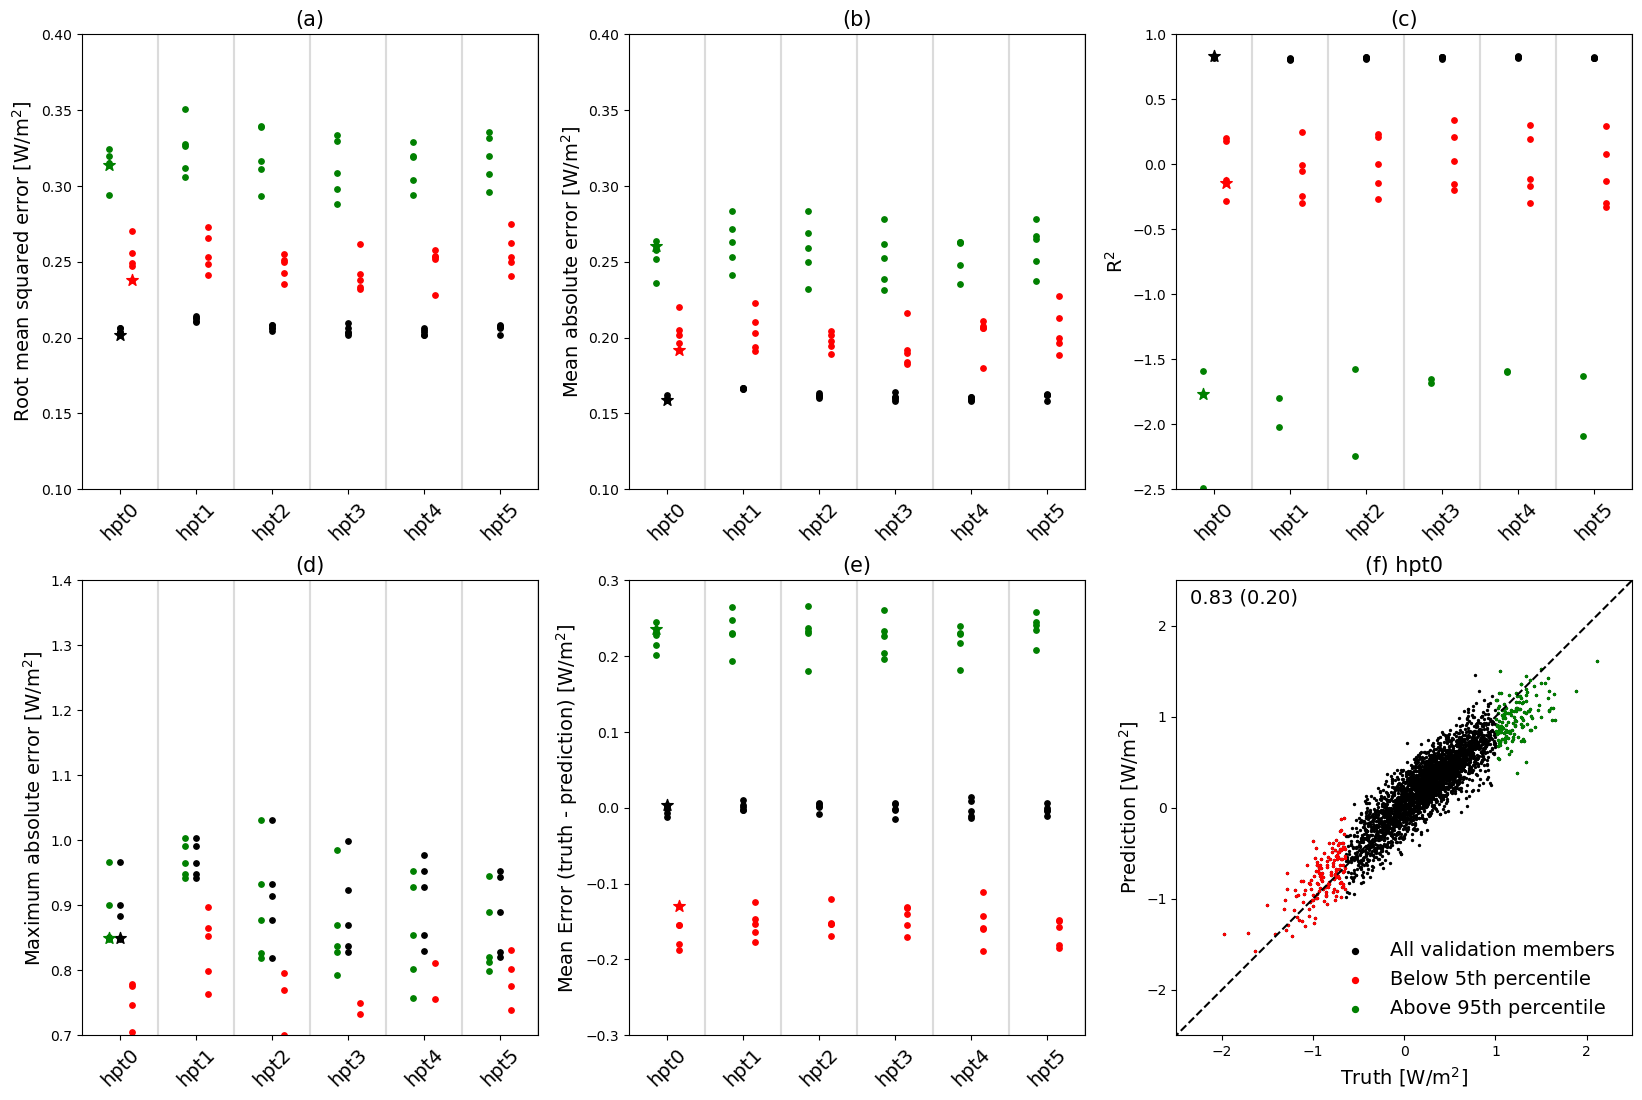

In [31]:
best_seed, best_model = best_mem_MSE
print("Best model: seed = "+str(best_seed)+"; hpt = "+str(best_model))

lbls = ["hpt"+str(ii).zfill(1) for ii in range(n_hpts)]
best_label = lbls[best_model]

RMSE = np.sqrt(MSE)
RMSE_5 = np.sqrt(MSE_5)
RMSE_95 = np.sqrt(MSE_95)

exp_num = np.arange(n_hpts)
PLOT = np.empty(5,dtype='object')

fig, axs = plt.subplots(2,3,figsize=(20, 13))
for qt in range(3):
    if qt==0:
        PLOT = np.array([RMSE, MAE, R2, MXE, ME])
        shift = 0.0
        clr = 'k'
    elif qt==1:
        PLOT = np.array([RMSE_5, MAE_5, R2_5, MXE_5, ME_5])
        shift = 0.15
        clr = 'r'
    elif qt==2:
        PLOT = np.array([RMSE_95, MAE_95, R2_95, MXE_95, ME_95])
        shift =-0.15
        clr = 'g'


    for jj in range(5):
        # if qt>0 and jj==1:
        #     continue
        ax = plt.subplot(2, 3, jj+1)
        for ii, seed in enumerate(seed_lst):
            ax.scatter(exp_num+shift,PLOT[jj,ii,:],color=clr,s=15)
        if best_model is not None:
            ax.scatter(best_model+shift,PLOT[jj,best_seed,best_model],marker='*',color=clr,s=75)

        for val in exp_num:
            ax.plot([val+0.5,val+0.5],[-10,10],color='gray',alpha=0.1)

        if qt==0:
            ax.set_xlim(-0.5,val+0.5)
            ax.set_xticks(range(n_hpts))
            ax.set_xticklabels(lbls, rotation=45,fontsize=14)
            if jj == 0:
                ax.set_ylabel("Root mean squared error [W/m$^2$]",fontsize=14)
                ax.set_ylim(0.1,0.4)
                ax.set_title("(a)",fontsize=15)
            elif jj == 1:
                ax.set_ylabel("Mean absolute error [W/m$^2$]",fontsize=14)
                ax.set_ylim(0.1,0.4)
                ax.set_title("(b)",fontsize=15)
            elif jj == 2:
                ax.set_ylabel("R$^2$",fontsize=14)
                ax.set_ylim(-2.5,1)
                ax.set_title("(c)",fontsize=15)
            elif jj == 3:
                ax.set_ylabel("Maximum absolute error [W/m$^2$]",fontsize=14)
                ax.set_ylim(0.7,1.4)
                ax.set_title("(d)",fontsize=15)
            elif jj == 4:
                ax.set_ylabel("Mean Error (truth - prediction) [W/m$^2$]",fontsize=14)
                ax.set_ylim(-0.3,0.3)
                ax.set_title("(e)",fontsize=15)
    
if best_model is None:
    best_model = 0

# Load predictions
label5, preds5, label95, preds95 = get_percentiles(true[test_set][best_seed,best_model], pred[test_set][best_seed,best_model], th=percentile_th)

ax = plt.subplot(2, 3, 6)
if test_set == 'val':
    ax.scatter(true[test_set][best_seed,best_model], pred[test_set][best_seed,best_model],s=2,color='k',label="All validation members")
elif test_set == 'test':
    ax.scatter(true[test_set][best_seed,best_model], pred[test_set][best_seed,best_model],s=2,color='k',label="All testing members")
ax.scatter(label5, preds5,s=2,color='r',label="Below "+str(percentile_th)+"th percentile")
ax.scatter(label95, preds95,s=2,color='g',label="Above "+str(100-percentile_th)+"th percentile")
ax.plot([-3.5,3.5],[-3.5,3.5],'k--')
ax.set_xlim(-2.5,2.5)
ax.set_ylim(-2.5,2.5)
ax.set_xlabel("Truth [W/m$^2$]",fontsize=14)
ax.set_ylabel("Prediction [W/m$^2$]",fontsize=14)
ax.set_title("(f) "+best_label,fontsize=15)
ax.legend(fontsize=14,markerscale=3,frameon=False)

ax.text(0.03, 0.95, \
        plotting.num_lab(R2[best_seed,best_model],2).ljust(4,'0') + " (" + plotting.num_lab(RMSE[best_seed,best_model],2).ljust(4,'0') + ')',transform=ax.transAxes, fontsize=14, horizontalalignment='left')

if SAVE_FILES:
    fig.savefig("./figures/hpt_"+hpt+"_"+test_set+".pdf",bbox_inches='tight',pad_inches = 0, dpi=300)

In [21]:
def save_map(figname,lon,lat,x,norm,crs,cmap):
    fig, ax = plotting.setup_figure("global",nCols=1,nRows=1,size=(10,8),mask=False)
    ax.pcolormesh(lon,lat,x,norm=norm,transform=crs,cmap=cmap)

    fig.savefig(figname,bbox_inches='tight',pad_inches = 0,dpi=300)
    plt.close()

-12.081869 6.4394913


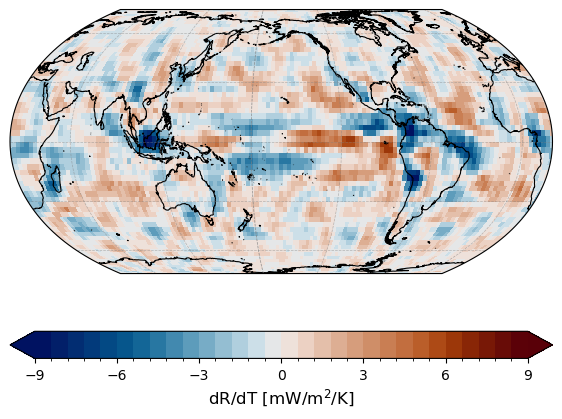

In [22]:


seed = seed_lst[best_seed]
(
    config,
    model,
    data,
    trainset,
    valset,
    testset,
) = load_utils.load_model_and_data(hpt_lst[best_model], seed, verbose=False)

# Calculate gradients
grads = load_utils.get_gradient(model, dataset=trainset, device='mps')
if config["datamaker"]["input_mask"]:
    input_mask = xr.open_dataarray(SHAPE_DIRECTORY + config["datamaker"]["input_mask"]).values
    input_mask = input_mask.astype(np.float32)
    input_mask[input_mask == 0] = np.nan
    grads = grads * input_mask[None, None, :, :]


l = np.linspace(-9,9,31)
t = np.linspace(-9,9,7)
norm = mpl.colors.BoundaryNorm(l, cmr.vik.N)

fig, ax = plotting.setup_figure('global',nCols=1,nRows=1,size=(7,5),mask=False)
ax.set_facecolor([0.8,0.8,0.8])
cf = ax.pcolormesh(data.input_lon,data.input_lat, 1e3*grads.mean(axis=(0,1)),transform=plotting.data_crs, cmap=cmr.vik ,norm=norm)
cb = plt.colorbar(cf,ax=ax, orientation = "horizontal",shrink=1.0, extend='both',ticks=t)
cb.set_label('dR/dT [mW/m$^2$/K]', fontsize=12)

if SAVE_FILES:
    save_map(
        './figures/CNN_grad_'+config['expname']+'_s'+str(seed)+'.png',
        data.input_lon,
        data.input_lat,
        1e3*grads.mean(axis=(0,1)),
        norm,
        plotting.data_crs,
        cmr.vik
    )

print(np.min(1e3*grads.mean(axis=(0,1))), np.max(1e3*grads.mean(axis=(0,1))))

In [25]:
if NETW_NAME[-10:] == '_hptesting':
    print("& Convolutional layers & Dense layers & learning rate")
    for jj, (hpt, lbl) in enumerate(zip(hpts,lbls)):
        hpt = hpts[hpt]
        print(hpt.keys())
        print(
            lbl+\
            " & "+str(hpt['arch']['filters']).ljust(12)+\
            " & "+str(hpt['arch']['hiddens']).ljust(8)+\
            " & "+str(hpt['optimizer']['args']['lr']).ljust(5)+"\\\\"
        )

& Convolutional layers & Dense layers & learning rate
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt0 & [32, 32]     & [32, 16] & 1e-05\\
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt1 & [32, 32, 32] & [32, 16] & 1e-05\\
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt2 & [32, 32]     & [32, 16] & 1e-05\\
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt3 & [32, 32]     & [16, 8]  & 1e-05\\
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt4 & [32, 32]     & [32, 16] & 0.0001\\
dict_keys(['arch', 'optimizer', 'best_seed'])
hpt5 & [16, 16]     & [32, 16] & 1e-05\\
